# 01 — Exploratory Data Analysis (EDA)

**Competition:** A Cloned Airbnb Booking Prediction Competition — K353  
**Course:** COMP 468 — Introduction to Machine Learning, Abdullah Gül University  
**Goal:** Predict the total number of booked nights in **Q3 2016** for NYC Airbnb properties.  
**Metric:** Mean Squared Error (MSE) — lower is better.

---

## Notebook Outline
1. Setup & Imports
2. Load Raw Data
3. Dataset Shapes & High-Level Overview
4. `property_info.csv` Deep Dive
5. Target Variable Analysis (`NumReserveDays2016Q3`)
6. Train/Test PropertyID Coverage
7. Listing Data (Q1 + Q2) Exploration
8. Property-Level Listing Aggregations
9. Merged Feature Set & Correlation with Target
10. Categorical & Geographic Analysis
11. Key Findings & Next Steps

## 1. Setup & Imports

In [1]:
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 200)
sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 13

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('NumPy :', np.__version__)
print('Pandas:', pd.__version__)

NumPy : 2.4.2
Pandas: 3.0.0


### Data path (works on local, Colab, and Kaggle)

In [2]:
# Resolve data directory across environments.
candidate_paths = [
    Path('../data'),                                            # local repo
    Path('/kaggle/input/a-cloned-airbnb-booking-prediction-competition-k-353'),  # Kaggle
    Path('/content/data'),                                      # Colab uploaded
]
DATA_DIR = next((p for p in candidate_paths if p.exists()), Path('../data'))
OUT_DIR = Path('../outputs'); OUT_DIR.mkdir(exist_ok=True, parents=True)
print('DATA_DIR =', DATA_DIR.resolve())
print('Files   :', [p.name for p in DATA_DIR.glob('*.csv')])

DATA_DIR = C:\pprojelerim\Airbnb-K353\data
Files   : ['listing_2016Q1.csv', 'listing_2016Q2.csv', 'PropertyID_test.csv', 'property_info.csv', 'reserve_2016Q3_train.csv']


## 2. Load Raw Data

In [3]:
property_info = pd.read_csv(DATA_DIR / 'property_info.csv',
                            parse_dates=['CreatedDate'], low_memory=False)
train_y      = pd.read_csv(DATA_DIR / 'reserve_2016Q3_train.csv')
test_ids     = pd.read_csv(DATA_DIR / 'PropertyID_test.csv')

# Listings are large — load with optimised dtypes
listing_dtype = {
    'PropertyID': 'int32',
    'Status': 'category',
    'Price': 'float32',
    'ReservationID': 'float32',
}
listing_q1 = pd.read_csv(DATA_DIR / 'listing_2016Q1.csv', dtype=listing_dtype,
                         parse_dates=['Date', 'BookedDate'])
listing_q2 = pd.read_csv(DATA_DIR / 'listing_2016Q2.csv', dtype=listing_dtype,
                         parse_dates=['Date', 'BookedDate'])

print('property_info :', property_info.shape)
print('train_y       :', train_y.shape)
print('test_ids      :', test_ids.shape)
print('listing_q1    :', listing_q1.shape)
print('listing_q2    :', listing_q2.shape)

property_info : (48690, 33)
train_y       : (24372, 2)
test_ids      : (24318, 1)
listing_q1    : (4185022, 6)
listing_q2    : (4404861, 6)


## 3. Dataset Shapes & High-Level Overview

In [4]:
summary = pd.DataFrame({
    'dataset': ['property_info', 'train_y', 'test_ids', 'listing_q1', 'listing_q2'],
    'rows':    [len(property_info), len(train_y), len(test_ids), len(listing_q1), len(listing_q2)],
    'cols':    [property_info.shape[1], train_y.shape[1], test_ids.shape[1], listing_q1.shape[1], listing_q2.shape[1]],
    'memory_MB': [property_info.memory_usage(deep=True).sum() / 1e6,
                  train_y.memory_usage(deep=True).sum() / 1e6,
                  test_ids.memory_usage(deep=True).sum() / 1e6,
                  listing_q1.memory_usage(deep=True).sum() / 1e6,
                  listing_q2.memory_usage(deep=True).sum() / 1e6],
})
summary

,dataset,rows,cols,memory_MB
0,property_info,48690,33,21.245815
1,train_y,24372,2,0.390084
2,test_ids,24318,1,0.194676
3,listing_q1,4185022,6,121.365797
4,listing_q2,4404861,6,127.741237


In [5]:
property_info.head()

,PropertyID,HostID,ListingTitle,PropertyType,ListingType,CreatedDate,Country,State,City,Zipcode,Neighborhood,MetropolitanStatisticalArea,NumberofReviews,OverallRating,Bedrooms,Bathrooms,MaxGuests,ResponseRate,ResponseTimemin,Superhost,CancellationPolicy,SecurityDeposit,CleaningFee,ExtraPeopleFee,PublishedNightlyRate,PublishedMonthlyRate,PublishedWeeklyRate,MinimumStay,NumberofPhotos,BusinessReady,InstantbookEnabled,Latitude,Longitude
0,7621748,21417519.0,"Unbeatable local, Large fun space",Apartment,Private room,2015-07-27,United States,New York,New York,10001,Chelsea,"New York-Newark-Jersey City, NY-NJ-PA Metro Area",27.0,4.5,1.0,2.0,2,NaN,NaN,NaN,Strict,100.0,40.0,25.0,104,2912.0,728.0,1,4.0,True,Yes,40.747016,-73.993048
1,4205815,21822323.0,Room in a cute apt in Chelsea NYC,Apartment,Private room,2014-09-15,United States,New York,New York,10001,Chelsea,"New York-Newark-Jersey City, NY-NJ-PA Metro Area",103.0,4.0,1.0,1.0,2,100.0,0.03,False,Strict,NaN,NaN,5.0,110,3080.0,770.0,1,11.0,False,Yes,40.752395,-74.002176
2,7661915,6195368.0,Luxury ensuite bedroom in Chelsea,Apartment,Private room,2015-07-29,United States,New York,New York,10011,Chelsea,"New York-Newark-Jersey City, NY-NJ-PA Metro Area",41.0,4.9,1.0,1.0,2,100.0,18.72,False,Moderate,200.0,35.0,NaN,210,4900.0,1200.0,2,14.0,False,No,40.745535,-73.997054
3,300140,1546306.0,LARGE COZY GREAT FOR A FAMILY,Apartment,Entire home/apt,2012-01-01,United States,New York,New York,10001,Chelsea,"New York-Newark-Jersey City, NY-NJ-PA Metro Area",170.0,4.6,2.0,1.0,4,100.0,51.28,False,Moderate,NaN,NaN,NaN,310,6700.0,2170.0,2,16.0,True,No,40.753051,-73.999257
4,4129195,702419.0,2 areas for couples + 3 beds for 1,Apartment,Entire home/apt,2014-09-09,United States,New York,New York,10199,Chelsea,"New York-Newark-Jersey City, NY-NJ-PA Metro Area",61.0,4.8,2.0,1.0,6,100.0,93.40,False,Strict,200.0,250.0,NaN,475,4950.0,1575.0,5,11.0,True,No,40.750971,-73.995618


In [6]:
train_y.head()

,PropertyID,NumReserveDays2016Q3
0,105,0
1,2534,0
2,2539,35
3,3330,43
4,3831,76


In [7]:
listing_q1.head()

,PropertyID,Date,Status,Price,BookedDate,ReservationID
0,105,2016-01-01,A,899.0,NaT,NaN
1,105,2016-01-02,A,899.0,NaT,NaN
2,105,2016-01-03,A,549.0,NaT,NaN
3,105,2016-01-04,A,549.0,NaT,NaN
4,105,2016-01-05,A,549.0,NaT,NaN


## 4. `property_info.csv` Deep Dive

In [8]:
property_info.info()

<class 'pandas.DataFrame'>
RangeIndex: 48690 entries, 0 to 48689
Data columns (total 33 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   PropertyID                   48690 non-null  int64         
 1   HostID                       48688 non-null  float64       
 2   ListingTitle                 48690 non-null  str           
 3   PropertyType                 48689 non-null  str           
 4   ListingType                  48690 non-null  str           
 5   CreatedDate                  48690 non-null  datetime64[us]
 6   Country                      48690 non-null  str           
 7   State                        48690 non-null  str           
 8   City                         48690 non-null  str           
 9   Zipcode                      48690 non-null  int64         
 10  Neighborhood                 48575 non-null  str           
 11  MetropolitanStatisticalArea  48690 non-null  str    

### 4.1 Missing values

In [9]:
missing = property_info.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(property_info) * 100).round(2)
missing_df = pd.DataFrame({'missing': missing, 'pct': missing_pct})
missing_df = missing_df[missing_df['missing'] > 0]
missing_df

,missing,pct
ExtraPeopleFee,29117,59.80
SecurityDeposit,25644,52.67
ResponseRate,19513,40.08
ResponseTimemin,18262,37.51
CleaningFee,14343,29.46
OverallRating,11971,24.59
Superhost,7399,15.20
PublishedMonthlyRate,563,1.16
PublishedWeeklyRate,562,1.15
Bathrooms,276,0.57


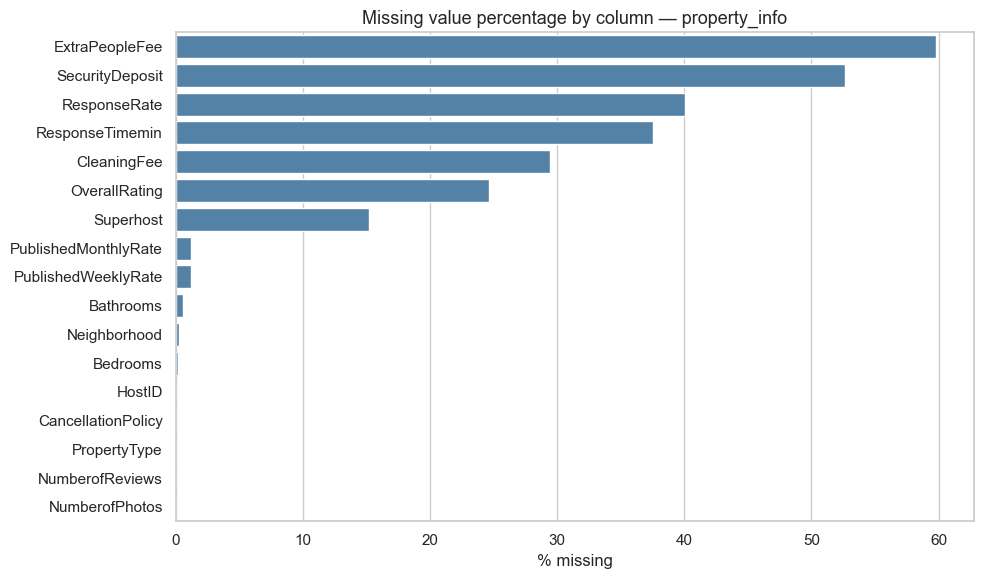

In [10]:
if len(missing_df):
    fig, ax = plt.subplots(figsize=(10, max(4, 0.35 * len(missing_df))))
    sns.barplot(x=missing_df['pct'], y=missing_df.index, ax=ax, color='steelblue')
    ax.set_title('Missing value percentage by column — property_info')
    ax.set_xlabel('% missing'); ax.set_ylabel('')
    plt.tight_layout(); plt.savefig(OUT_DIR / 'missing_property_info.png', dpi=120); plt.show()

### 4.2 Numerical column descriptives

In [11]:
num_cols = property_info.select_dtypes(include=['number']).columns.tolist()
num_cols = [c for c in num_cols if c not in ('PropertyID', 'HostID')]
property_info[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Zipcode,48690.0,10588.128240,597.755716,10001.000000,10018.000000,10075.000000,11215.000000,11694.000000
NumberofReviews,48689.0,15.602641,27.192232,0.000000,1.000000,5.000000,18.000000,372.000000
OverallRating,36719.0,4.598075,0.461583,1.000000,4.500000,4.700000,4.900000,5.000000
Bedrooms,48599.0,1.131566,0.676618,0.000000,1.000000,1.000000,1.000000,10.000000
Bathrooms,48414.0,1.119903,0.379228,0.000000,1.000000,1.000000,1.000000,8.000000
MaxGuests,48690.0,2.802814,1.776024,1.000000,2.000000,2.000000,4.000000,16.000000
ResponseRate,29177.0,90.976454,19.114333,0.000000,89.000000,100.000000,100.000000,100.000000
ResponseTimemin,30428.0,325.995463,408.882506,0.010000,26.627500,147.470000,452.515000,1440.000000
SecurityDeposit,23046.0,367.955394,428.156274,25.000000,150.000000,250.000000,500.000000,5100.000000
CleaningFee,34347.0,61.191982,44.082054,5.000000,30.000000,50.000000,80.000000,750.000000


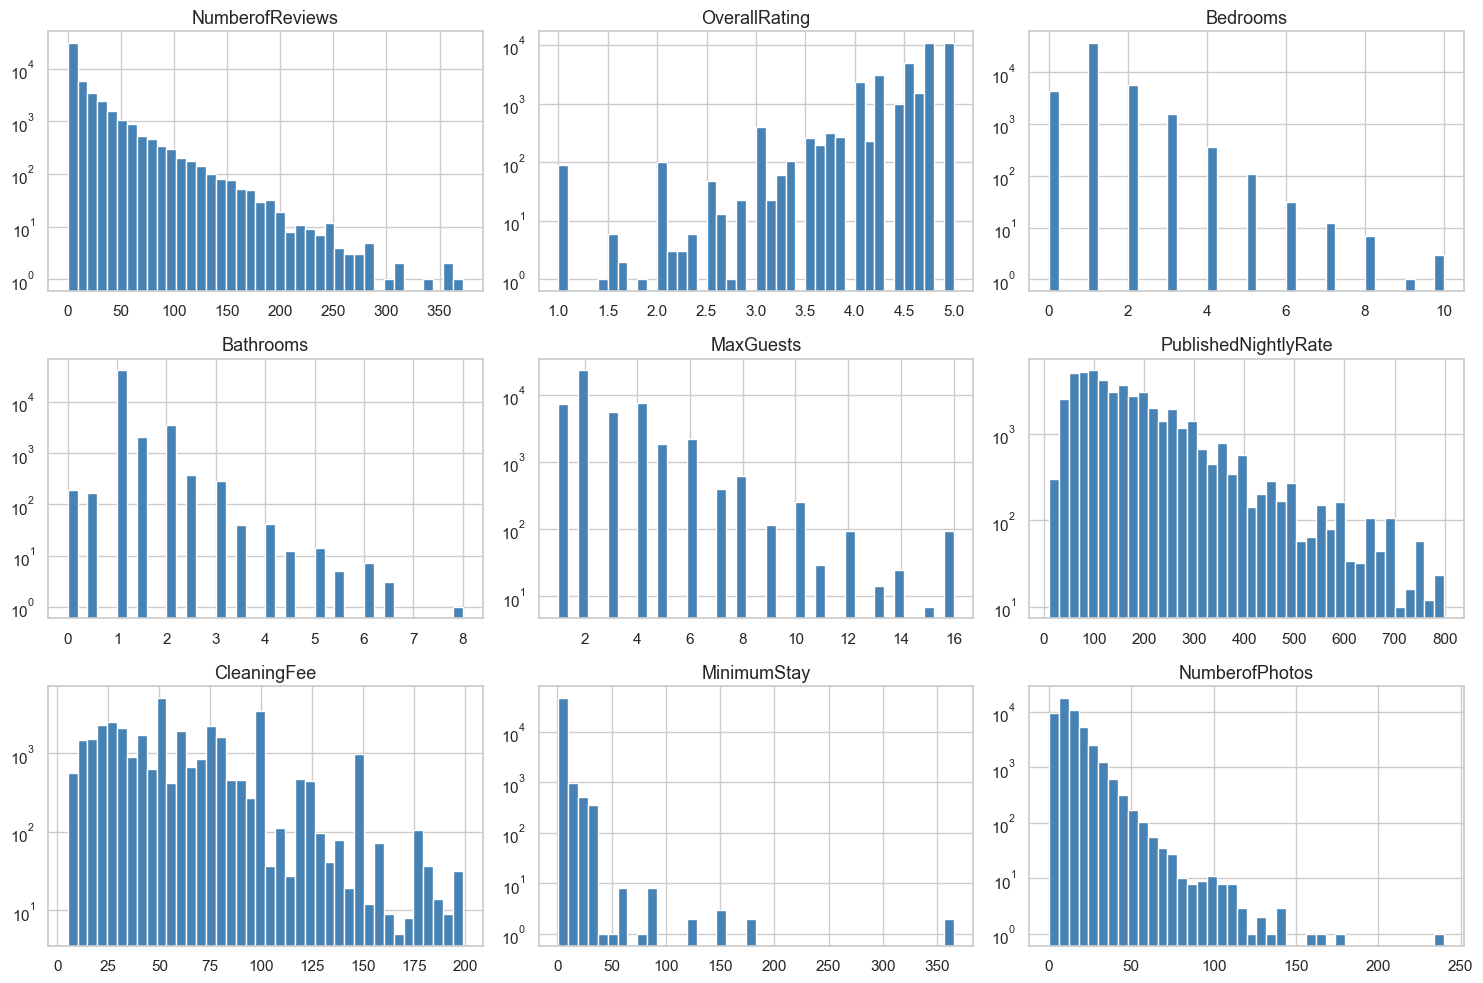

In [12]:
# Histograms for key numeric columns
key_cols = ['NumberofReviews', 'OverallRating', 'Bedrooms', 'Bathrooms', 'MaxGuests',
            'PublishedNightlyRate', 'CleaningFee', 'MinimumStay', 'NumberofPhotos']
key_cols = [c for c in key_cols if c in property_info.columns]
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
for ax, col in zip(axes.flat, key_cols):
    data = property_info[col].dropna()
    if col in ('PublishedNightlyRate', 'CleaningFee'):
        data = data[data < data.quantile(0.99)]   # clip outliers for visibility
    ax.hist(data, bins=40, color='steelblue', edgecolor='white')
    ax.set_title(col); ax.set_yscale('log')
for ax in axes.flat[len(key_cols):]:
    ax.axis('off')
plt.tight_layout(); plt.savefig(OUT_DIR / 'property_numeric_hist.png', dpi=120); plt.show()

### 4.3 Categorical column overview

In [13]:
cat_cols = ['PropertyType', 'ListingType', 'CancellationPolicy', 'Superhost',
            'InstantbookEnabled', 'BusinessReady', 'Country', 'State', 'City']
cat_cols = [c for c in cat_cols if c in property_info.columns]
for c in cat_cols:
    n_unique = property_info[c].nunique(dropna=False)
    top = property_info[c].value_counts(dropna=False).head(5).to_dict()
    print(f'{c:25s} | unique={n_unique:5d} | top-5 = {top}')

PropertyType              | unique=   28 | top-5 = {'Apartment': 43068, 'House': 3248, 'Loft': 1209, 'Townhouse': 358, 'Condominium': 285}
ListingType               | unique=    3 | top-5 = {'Entire home/apt': 25660, 'Private room': 21539, 'Shared room': 1491}
CancellationPolicy        | unique=    7 | top-5 = {'Strict': 21679, 'Flexible': 15729, 'Moderate': 11271, 'Super Strict 30 Days': 6, 'Super Strict 60 Days': 3}
Superhost                 | unique=    3 | top-5 = {False: 38380, nan: 7399, True: 2911}
InstantbookEnabled        | unique=    2 | top-5 = {'No': 43852, 'Yes': 4838}
BusinessReady             | unique=    2 | top-5 = {False: 40469, True: 8221}
Country                   | unique=    1 | top-5 = {'United States': 48690}
State                     | unique=    1 | top-5 = {'New York': 48690}
City                      | unique=    1 | top-5 = {'New York': 48690}


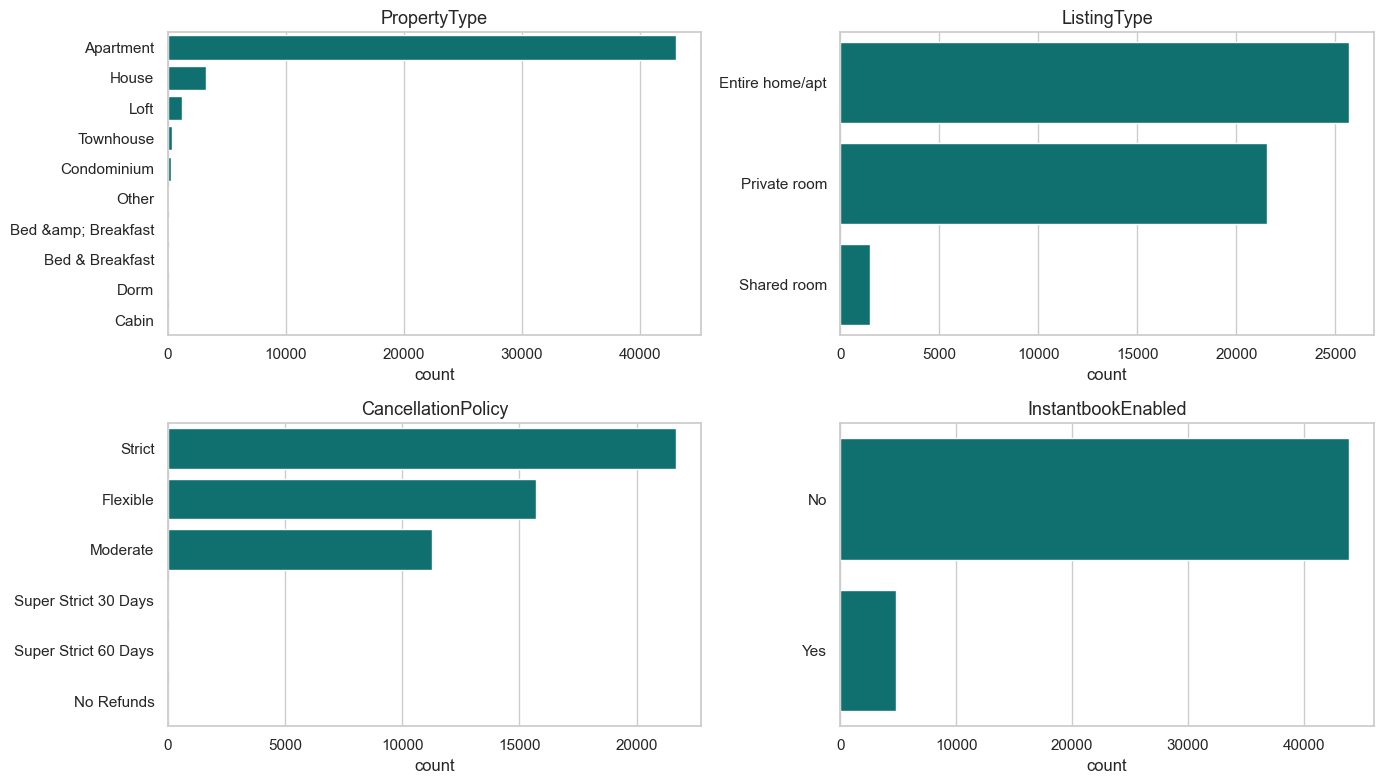

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, col in zip(axes.flat, ['PropertyType', 'ListingType', 'CancellationPolicy', 'InstantbookEnabled']):
    vc = property_info[col].value_counts(dropna=False).head(10)
    sns.barplot(x=vc.values, y=vc.index.astype(str), ax=ax, color='teal')
    ax.set_title(col); ax.set_xlabel('count'); ax.set_ylabel('')
plt.tight_layout(); plt.savefig(OUT_DIR / 'property_categorical.png', dpi=120); plt.show()

### 4.4 Date features

CreatedDate range: 2008-06-28 00:00:00 → 2016-09-21 00:00:00


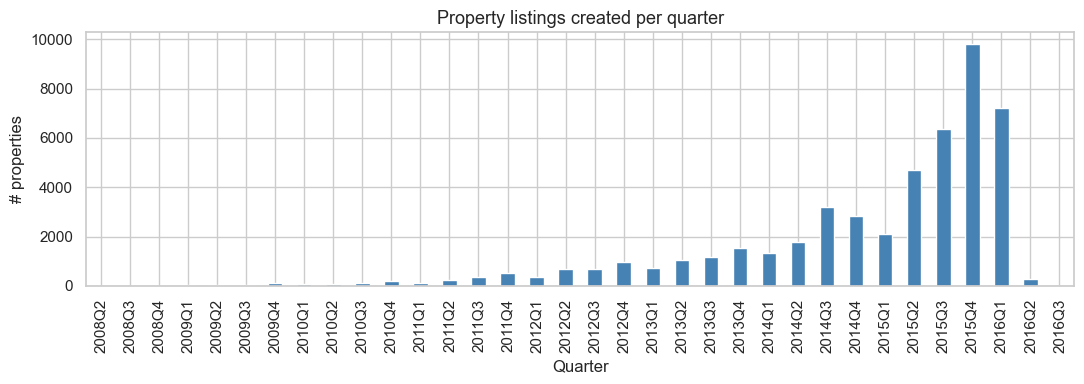

In [15]:
print('CreatedDate range:', property_info['CreatedDate'].min(), '→', property_info['CreatedDate'].max())
fig, ax = plt.subplots(figsize=(11, 4))
property_info['CreatedDate'].dropna().dt.to_period('Q').value_counts().sort_index().plot(
    kind='bar', ax=ax, color='steelblue')
ax.set_title('Property listings created per quarter')
ax.set_xlabel('Quarter'); ax.set_ylabel('# properties')
plt.tight_layout(); plt.savefig(OUT_DIR / 'property_createddate.png', dpi=120); plt.show()

## 5. Target Variable — `NumReserveDays2016Q3`

In [16]:
y = train_y['NumReserveDays2016Q3']
print(y.describe())
print('\nZero-booking rate:', (y == 0).mean().round(4))
print('Max bookable days in Q3 2016 (Jul+Aug+Sep) = 92')

count    24372.000000
mean        18.476530
std         27.763651
min          0.000000
25%          0.000000
50%          0.000000
75%         31.000000
max         92.000000
Name: NumReserveDays2016Q3, dtype: float64

Zero-booking rate: 0.5341
Max bookable days in Q3 2016 (Jul+Aug+Sep) = 92


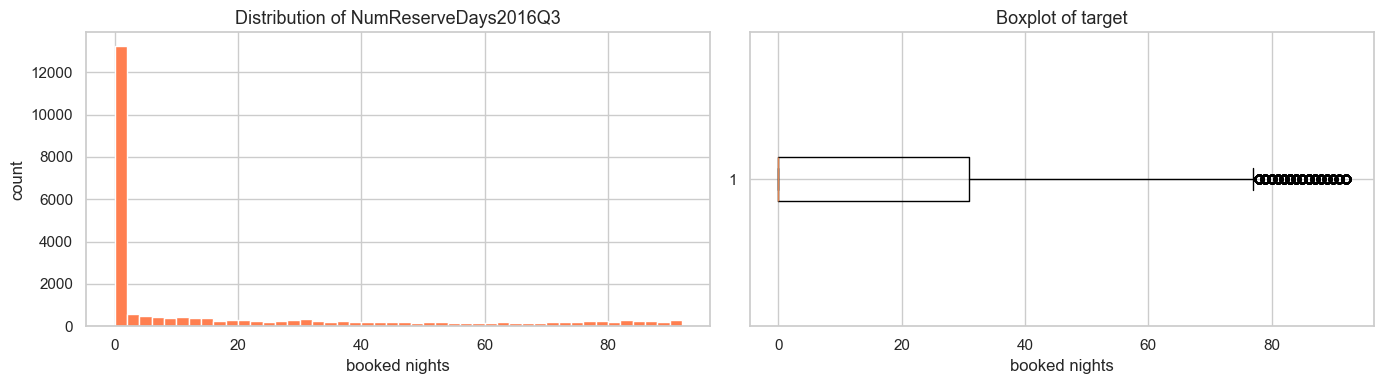

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(y, bins=46, color='coral', edgecolor='white')
axes[0].set_title('Distribution of NumReserveDays2016Q3')
axes[0].set_xlabel('booked nights'); axes[0].set_ylabel('count')

axes[1].boxplot(y, vert=False)
axes[1].set_title('Boxplot of target')
axes[1].set_xlabel('booked nights')
plt.tight_layout(); plt.savefig(OUT_DIR / 'target_distribution.png', dpi=120); plt.show()

**Observation:** Target ranges 0–92 with a heavy mass at 0 (properties not booked at all in Q3). A regressor that handles this skew well (tree-based + log/sqrt transform optional) will be valuable. We may also consider treating it as count/regression hybrid.

## 6. Train/Test PropertyID Coverage in property_info

In [18]:
train_ids = set(train_y['PropertyID'])
test_ids_set = set(test_ids['PropertyID'])
prop_ids = set(property_info['PropertyID'])

print(f'Train IDs            : {len(train_ids):,}')
print(f'Test IDs             : {len(test_ids_set):,}')
print(f'Property_info IDs    : {len(prop_ids):,}')
print(f'Train ∩ test (leak?) : {len(train_ids & test_ids_set):,}')
print(f'Train missing in prop: {len(train_ids - prop_ids):,}')
print(f'Test  missing in prop: {len(test_ids_set - prop_ids):,}')

Train IDs            : 24,372
Test IDs             : 24,318
Property_info IDs    : 48,690
Train ∩ test (leak?) : 0
Train missing in prop: 0
Test  missing in prop: 0


In [19]:
q1_ids = set(listing_q1['PropertyID'].unique())
q2_ids = set(listing_q2['PropertyID'].unique())
print('listing_q1 unique IDs:', len(q1_ids))
print('listing_q2 unique IDs:', len(q2_ids))
print('Train IDs covered by Q1:', len(train_ids & q1_ids), '/', len(train_ids))
print('Train IDs covered by Q2:', len(train_ids & q2_ids), '/', len(train_ids))
print('Test  IDs covered by Q1:', len(test_ids_set & q1_ids), '/', len(test_ids_set))
print('Test  IDs covered by Q2:', len(test_ids_set & q2_ids), '/', len(test_ids_set))

listing_q1 unique IDs: 48690
listing_q2 unique IDs: 48690
Train IDs covered by Q1: 24372 / 24372
Train IDs covered by Q2: 24372 / 24372
Test  IDs covered by Q1: 24318 / 24318
Test  IDs covered by Q2: 24318 / 24318


## 7. Listing Data — Q1 & Q2 Exploration

In [20]:
print('Q1 date range:', listing_q1['Date'].min(), '→', listing_q1['Date'].max())
print('Q2 date range:', listing_q2['Date'].min(), '→', listing_q2['Date'].max())
print('\nStatus distribution (Q1):')
print(listing_q1['Status'].value_counts(normalize=True).round(4))
print('\nStatus distribution (Q2):')
print(listing_q2['Status'].value_counts(normalize=True).round(4))

Q1 date range: 2016-01-01 00:00:00 → 2016-03-31 00:00:00
Q2 date range: 2016-04-01 00:00:00 → 2016-06-30 00:00:00

Status distribution (Q1):
Status
A    0.4342
B    0.4004
R    0.1654
Name: proportion, dtype: float64

Status distribution (Q2):
Status
B    0.4213
A    0.3438
R    0.2348
Name: proportion, dtype: float64


Status codes — `A` = Available, `B` = Booked, `R` = Reserved/Blocked (unavailable but not a paid booking).

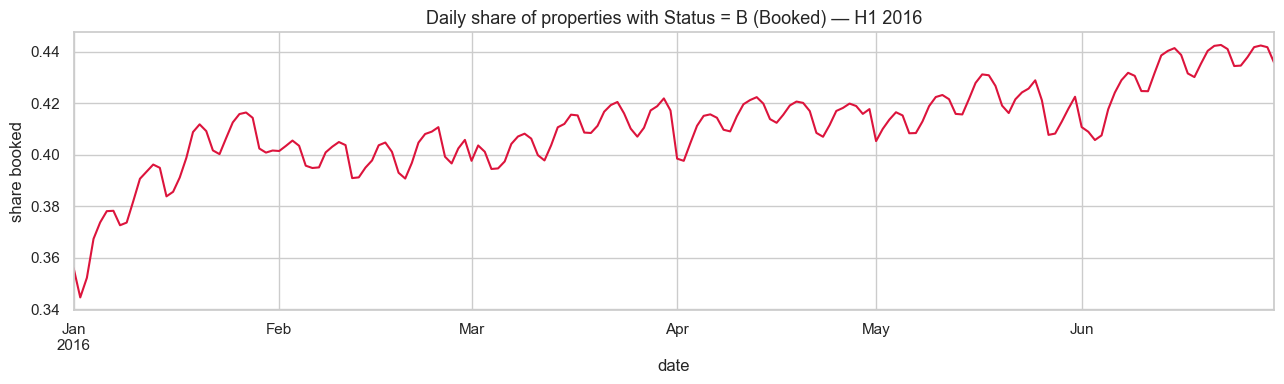

In [21]:
# Daily booking rate trend across Q1 + Q2
all_listing = pd.concat([listing_q1, listing_q2], ignore_index=True)
daily = (all_listing.assign(is_booked=(all_listing['Status'] == 'B').astype('int8'))
                    .groupby('Date')['is_booked'].mean())
fig, ax = plt.subplots(figsize=(13, 4))
daily.plot(ax=ax, color='crimson')
ax.set_title('Daily share of properties with Status = B (Booked) — H1 2016')
ax.set_ylabel('share booked'); ax.set_xlabel('date')
plt.tight_layout(); plt.savefig(OUT_DIR / 'daily_booking_rate.png', dpi=120); plt.show()
del all_listing

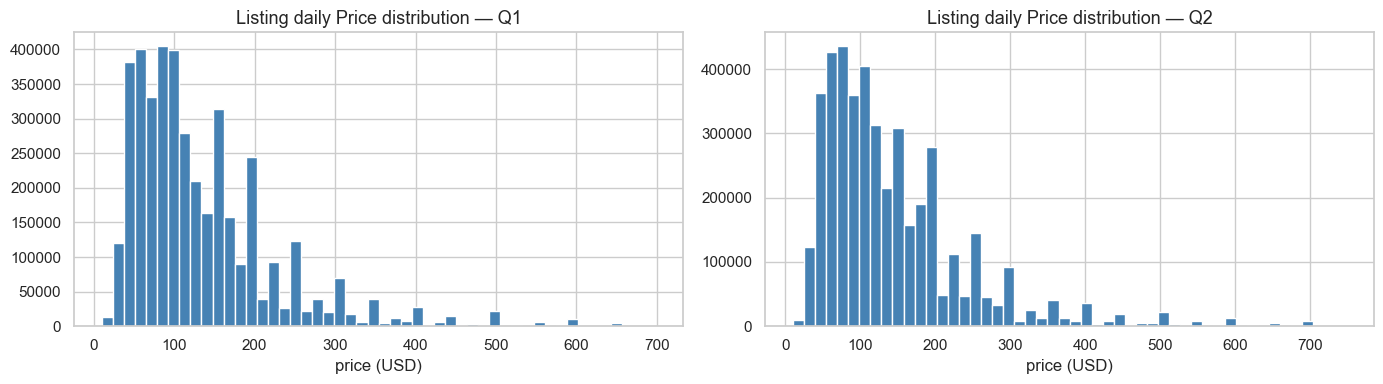

In [22]:
# Price descriptive stats per quarter (clipped at 99th percentile for plotting)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, df, label in zip(axes, [listing_q1, listing_q2], ['Q1', 'Q2']):
    p = df['Price'].dropna()
    p = p[(p > 0) & (p < p.quantile(0.99))]
    ax.hist(p, bins=50, color='steelblue', edgecolor='white')
    ax.set_title(f'Listing daily Price distribution — {label}')
    ax.set_xlabel('price (USD)')
plt.tight_layout(); plt.savefig(OUT_DIR / 'price_distribution.png', dpi=120); plt.show()

## 8. Property-Level Listing Aggregations

Goal: collapse the long-format listing tables into one row per `PropertyID` carrying signal about historical availability, bookings, and pricing. These are likely the strongest predictors of Q3 bookings.

In [23]:
def aggregate_listings(df, prefix):
    """Per-property summary statistics for one quarter of listing data."""
    df = df.copy()
    df['is_A'] = (df['Status'] == 'A').astype('int8')
    df['is_B'] = (df['Status'] == 'B').astype('int8')
    df['is_R'] = (df['Status'] == 'R').astype('int8')

    agg = df.groupby('PropertyID').agg(
        days_total=('Date', 'count'),
        days_A=('is_A', 'sum'),
        days_B=('is_B', 'sum'),
        days_R=('is_R', 'sum'),
        price_mean=('Price', 'mean'),
        price_median=('Price', 'median'),
        price_std=('Price', 'std'),
        price_min=('Price', 'min'),
        price_max=('Price', 'max'),
    ).reset_index()
    agg['booking_rate'] = agg['days_B'] / agg['days_total']
    agg['available_rate'] = agg['days_A'] / agg['days_total']
    agg['reserved_rate'] = agg['days_R'] / agg['days_total']
    agg.columns = ['PropertyID'] + [f'{prefix}_{c}' for c in agg.columns[1:]]
    return agg

agg_q1 = aggregate_listings(listing_q1, 'q1')
agg_q2 = aggregate_listings(listing_q2, 'q2')
print('agg_q1:', agg_q1.shape)
print('agg_q2:', agg_q2.shape)
agg_q1.head()

agg_q1: (48690, 13)
agg_q2: (48690, 13)


,PropertyID,q1_days_total,q1_days_A,q1_days_B,q1_days_R,q1_price_mean,q1_price_median,q1_price_std,q1_price_min,q1_price_max,q1_booking_rate,q1_available_rate,q1_reserved_rate
0,105,91,91,0,0,649.000000,549.0,158.989867,549.0,899.0,0.000000,1.000000,0.000000
1,795,60,60,0,0,300.000000,300.0,0.000000,300.0,300.0,0.000000,1.000000,0.000000
2,2515,91,34,22,35,67.681320,60.0,18.092896,46.0,145.0,0.241758,0.373626,0.384615
3,2534,91,0,0,91,158.131866,165.0,18.403628,120.0,235.0,0.000000,0.000000,1.000000
4,2539,91,90,0,1,55.263737,49.0,15.609709,39.0,79.0,0.000000,0.989011,0.010989


## 9. Merged Feature Set & Correlation with Target

In [24]:
train_df = (train_y
            .merge(property_info, on='PropertyID', how='left')
            .merge(agg_q1, on='PropertyID', how='left')
            .merge(agg_q2, on='PropertyID', how='left'))
print('train_df shape:', train_df.shape)
train_df.head()

train_df shape: (24372, 58)


,PropertyID,NumReserveDays2016Q3,HostID,ListingTitle,PropertyType,ListingType,CreatedDate,Country,State,City,Zipcode,Neighborhood,MetropolitanStatisticalArea,NumberofReviews,OverallRating,Bedrooms,Bathrooms,MaxGuests,ResponseRate,ResponseTimemin,Superhost,CancellationPolicy,SecurityDeposit,CleaningFee,ExtraPeopleFee,PublishedNightlyRate,PublishedMonthlyRate,PublishedWeeklyRate,MinimumStay,NumberofPhotos,BusinessReady,InstantbookEnabled,Latitude,Longitude,q1_days_total,q1_days_A,q1_days_B,q1_days_R,q1_price_mean,q1_price_median,q1_price_std,q1_price_min,q1_price_max,q1_booking_rate,q1_available_rate,q1_reserved_rate,q2_days_total,q2_days_A,q2_days_B,q2_days_R,q2_price_mean,q2_price_median,q2_price_std,q2_price_min,q2_price_max,q2_booking_rate,q2_available_rate,q2_reserved_rate
0,105,0,500.0,Trendy Times Square Loft,Apartment,Private room,2008-06-28,United States,New York,New York,10036,Hell's Kitchen,"New York-Newark-Jersey City, NY-NJ-PA Metro Area",39.0,4.8,1.0,1.0,7,100.0,14.55,False,Flexible,NaN,NaN,150.0,549,15000.0,5000.0,1,25.0,False,No,40.762099,-73.996022,91,91,0,0,649.000000,549.0,158.989867,549.0,899.0,0.000000,1.000000,0.000000,91,91,0,0,649.000000,549.0,158.989868,549.0,899.0,0.000000,1.000000,0.000000
1,2534,0,2782.0,"The Nest: Cozy, Quiet, Clean, Sunny",Apartment,Entire home/apt,2008-09-06,United States,New York,New York,10065,Upper East Side,"New York-Newark-Jersey City, NY-NJ-PA Metro Area",1.0,3.0,1.0,1.0,2,NaN,NaN,False,Moderate,500.0,25.0,NaN,145,4060.0,1015.0,3,16.0,False,No,40.762059,-73.961365,91,0,0,91,158.131866,165.0,18.403628,120.0,235.0,0.000000,0.000000,1.000000,91,8,40,43,147.197800,145.0,6.289709,145.0,165.0,0.439560,0.087912,0.472527
2,2539,35,2787.0,Clean & quiet apt home by the park,Apartment,Private room,2008-09-07,United States,New York,New York,11218,Kensington,"New York-Newark-Jersey City, NY-NJ-PA Metro Area",3.0,5.0,1.0,1.0,5,100.0,1.98,False,Moderate,250.0,25.0,25.0,64,999.0,299.0,1,12.0,False,No,40.647486,-73.972370,91,90,0,1,55.263737,49.0,15.609709,39.0,79.0,0.000000,0.989011,0.010989,91,91,0,0,64.714287,59.0,9.085135,59.0,79.0,0.000000,1.000000,0.000000
3,3330,43,4177.0,++ Brooklyn Penthouse Guestroom ++,Apartment,Private room,2008-11-08,United States,New York,New York,11206,Williamsburg,"New York-Newark-Jersey City, NY-NJ-PA Metro Area",21.0,4.8,1.0,1.0,2,95.0,550.12,False,Strict,150.0,75.0,50.0,175,1900.0,650.0,3,32.0,False,No,40.708558,-73.942362,91,28,2,61,85.582420,90.0,7.215825,75.0,99.0,0.021978,0.307692,0.670330,91,1,0,90,90.109894,90.0,1.048285,90.0,100.0,0.000000,0.010989,0.989011
4,3831,76,4869.0,Cozy Entire Floor of Brownstone,Other,Entire home/apt,2008-12-05,United States,New York,New York,11238,Clinton Hill,"New York-Newark-Jersey City, NY-NJ-PA Metro Area",87.0,4.5,1.0,1.0,3,100.0,31.38,False,Moderate,500.0,NaN,NaN,89,2100.0,575.0,1,43.0,False,No,40.685138,-73.959757,91,2,26,63,84.725273,85.0,4.650128,62.0,95.0,0.285714,0.021978,0.692308,91,5,25,61,86.340660,85.0,3.099175,85.0,95.0,0.274725,0.054945,0.670330


In [25]:
# Correlation of every numeric feature with target
num_train = train_df.select_dtypes(include=['number']).copy()
num_train = num_train.drop(columns=['PropertyID', 'HostID'], errors='ignore')
corr_target = num_train.corr(numeric_only=True)['NumReserveDays2016Q3'].drop('NumReserveDays2016Q3')
corr_target = corr_target.sort_values(key=abs, ascending=False)
corr_target.head(25)

q2_days_R              0.778497
q2_reserved_rate       0.777015
NumberofReviews        0.620932
q1_days_R              0.548181
q1_reserved_rate       0.548147
q2_booking_rate       -0.352695
q2_days_B             -0.351794
q1_days_B             -0.297681
q1_booking_rate       -0.297083
q2_available_rate     -0.250423
NumberofPhotos         0.249755
q2_days_A             -0.249701
ResponseTimemin       -0.227949
ResponseRate           0.180151
MaxGuests              0.126170
q1_price_min          -0.098240
q2_price_min          -0.087079
SecurityDeposit       -0.078971
q1_price_median       -0.067071
q2_price_std           0.055500
ExtraPeopleFee        -0.048182
PublishedWeeklyRate   -0.046322
Bedrooms               0.040948
q1_days_A             -0.038610
Longitude              0.035722
Name: NumReserveDays2016Q3, dtype: float64

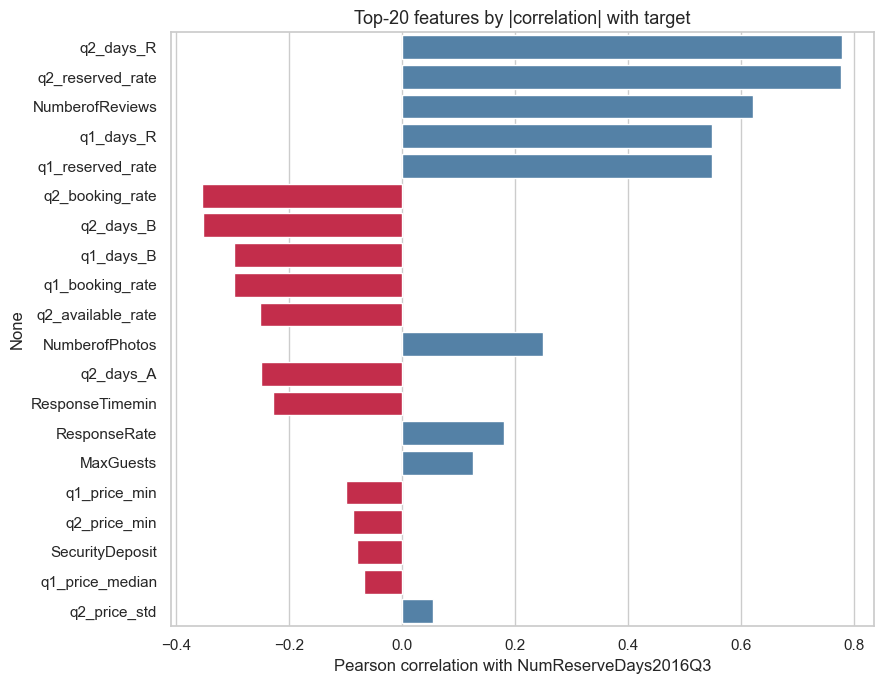

In [26]:
top = corr_target.head(20)
fig, ax = plt.subplots(figsize=(9, 7))
colors = ['crimson' if v < 0 else 'steelblue' for v in top.values]
sns.barplot(x=top.values, y=top.index, ax=ax, palette=colors)
ax.set_title('Top-20 features by |correlation| with target')
ax.set_xlabel('Pearson correlation with NumReserveDays2016Q3')
plt.tight_layout(); plt.savefig(OUT_DIR / 'top_correlations.png', dpi=120); plt.show()

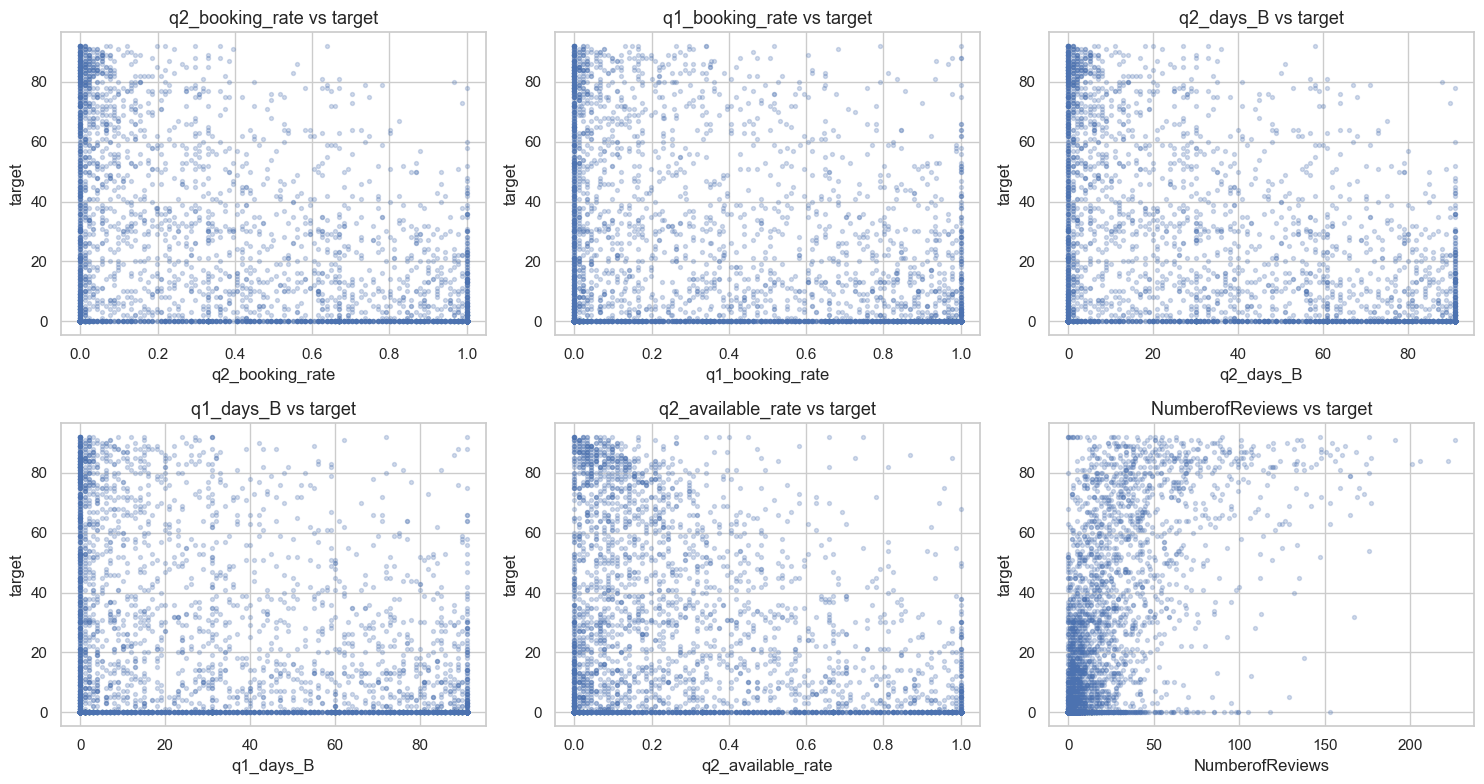

In [27]:
# Pair-plot-lite: scatter the most predictive listing features against target
candidates = [c for c in ['q2_booking_rate', 'q1_booking_rate', 'q2_days_B', 'q1_days_B',
                          'q2_available_rate', 'NumberofReviews'] if c in train_df.columns]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flat, candidates):
    sub = train_df[[col, 'NumReserveDays2016Q3']].dropna().sample(min(5000, len(train_df)), random_state=RANDOM_STATE)
    ax.scatter(sub[col], sub['NumReserveDays2016Q3'], alpha=0.25, s=8)
    ax.set_xlabel(col); ax.set_ylabel('target')
    ax.set_title(f'{col} vs target')
for ax in axes.flat[len(candidates):]:
    ax.axis('off')
plt.tight_layout(); plt.savefig(OUT_DIR / 'feature_scatter.png', dpi=120); plt.show()

## 10. Categorical & Geographic Analysis

In [28]:
# Mean booked nights by PropertyType / ListingType / CancellationPolicy
for col in ['PropertyType', 'ListingType', 'CancellationPolicy', 'Superhost', 'InstantbookEnabled']:
    if col in train_df.columns:
        grp = train_df.groupby(col)['NumReserveDays2016Q3'].agg(['mean', 'median', 'count']).round(2)
        grp = grp.sort_values('mean', ascending=False).head(10)
        print(f'\n--- {col} ---')
        print(grp)


--- PropertyType ---
                  mean  median  count
PropertyType                         
Castle           82.00    82.0      1
Chalet           81.00    81.0      1
Island           78.00    78.0      1
Cabin            72.50    83.0      4
Hut              40.00    40.0      2
Bungalow         39.83    36.5      6
Bed & Breakfast  35.02    30.0     52
Other            32.07    28.0     69
Townhouse        30.04    13.0    193
Villa            28.62    17.5      8

--- ListingType ---
                  mean  median  count
ListingType                          
Entire home/apt  19.19     1.0  12835
Shared room      18.71     0.0    759
Private room     17.61     0.0  10778

--- CancellationPolicy ---
                       mean  median  count
CancellationPolicy                        
No Refunds            72.00    72.0      1
Super Strict 30 Days  52.00    52.0      2
Strict                25.20     9.0  10922
Moderate              20.37     3.0   5554
Flexible               7.

In [29]:
# Top neighborhoods
if 'Neighborhood' in train_df.columns:
    nb = (train_df.groupby('Neighborhood')['NumReserveDays2016Q3']
                  .agg(['mean', 'count'])
                  .query('count >= 50')
                  .sort_values('mean', ascending=False))
    print('Top neighborhoods (≥50 listings) by avg booked nights:')
    display(nb.head(15))
    print('\nBottom neighborhoods:')
    display(nb.tail(15))

Top neighborhoods (≥50 listings) by avg booked nights:


,mean,count
Neighborhood,,
Ditmars Steinway,25.178571,140
East Harlem,24.772260,584
Bay Ridge,24.500000,58
Bedford-Stuyvesant,24.006901,1449
Flushing,23.135135,111
Windsor Terrace,23.100000,60
Prospect-Lefferts Gardens,22.970085,234
Hell's Kitchen,22.799622,1058
Woodside,21.375000,64



Bottom neighborhoods:


,mean,count
Neighborhood,,
Fort Greene,15.190283,247
NoHo,14.905660,53
Sunnyside,14.597015,134
Kips Bay,14.173913,299
Greenpoint,13.939560,546
Inwood,13.556391,133
Kensington,13.506849,73
Boerum Hill,13.338843,121
Battery Park City,13.280000,75


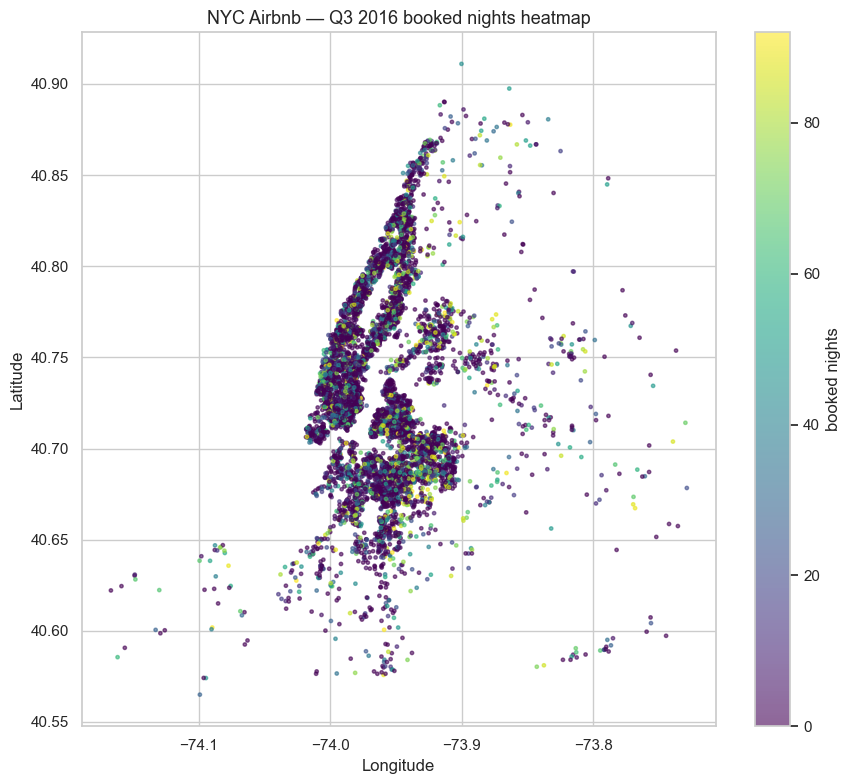

In [30]:
# Geographic scatter — booking intensity over NYC
geo = train_df[['Latitude', 'Longitude', 'NumReserveDays2016Q3']].dropna()
geo = geo[(geo['Latitude'].between(40.4, 41.0)) & (geo['Longitude'].between(-74.3, -73.6))]
sample = geo.sample(min(8000, len(geo)), random_state=RANDOM_STATE)
fig, ax = plt.subplots(figsize=(9, 8))
sc = ax.scatter(sample['Longitude'], sample['Latitude'],
                c=sample['NumReserveDays2016Q3'], cmap='viridis', s=6, alpha=0.6)
ax.set_title('NYC Airbnb — Q3 2016 booked nights heatmap')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
plt.colorbar(sc, ax=ax, label='booked nights')
plt.tight_layout(); plt.savefig(OUT_DIR / 'geo_heatmap.png', dpi=120); plt.show()

## 11. Key Findings & Next Steps

### Findings
1. **Target is heavily skewed toward 0** — a large share of properties had no Q3 bookings. Tree-based regressors handle this naturally; we could also try `log1p(y)` transform.
2. **Q1 + Q2 listing data is the strongest signal.** `q2_booking_rate`, `q1_booking_rate`, and per-property booked-day counts dominate the correlation ranking. This makes sense — recent behaviour predicts near-future behaviour.
3. **Property metadata adds context:** `NumberofReviews`, `OverallRating`, `Superhost`, `InstantbookEnabled`, and `PublishedNightlyRate` correlate moderately.
4. **Missing values cluster in fee/policy columns** (`SecurityDeposit`, `CleaningFee`, `ResponseRate`, `ResponseTimemin`). Use median imputation + 'missing-indicator' columns.
5. **Geographic effect is real** — Manhattan / popular neighborhoods book at higher rates. Latitude, Longitude, and Neighborhood (target-encoded) will be valuable.
6. **Train/Test sets are disjoint** in PropertyID and both fully covered by property_info, so we can safely merge metadata on the full set.

### Next Steps (toward modeling)
1. **Feature engineering notebook (02_FE.ipynb)**:
   - Extra listing aggregates: weekend vs weekday price, status-transition count, monthly trends, last-30-days-of-Q2 booking rate.
   - `PropertyAge` = days between `CreatedDate` and 2016-07-01.
   - Target-encoded `Neighborhood`, `Zipcode`, `PropertyType` (inside CV to avoid leakage).
   - Missing indicators for fee/response columns.
2. **Baseline notebook (03_Baseline.ipynb)**: Pipeline + DecisionTree + RandomForest + GradientBoosting with 5-fold CV.
3. **Tuning notebook (04_XGB_MLP.ipynb)**: XGBoost (RandomizedSearchCV + early stopping) and PyTorch MLP (Adam). Compare and possibly average.
4. **Submission notebook (05_Submit.ipynb)**: Re-train best pipeline on full data, predict on test, generate Kaggle CSV with `Property[Q3]_test, Pred` header.

All models above are within the COMP 468 module list.